In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
df = pd.read_csv("data/resumes.csv")
df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [5]:
df.columns

Index(['address', 'career_objective', 'skills', 'educational_institution_name',
       'degree_names', 'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', 'extra_curricular_activity_types',
       'extra_curricular_organization_names',
       'extra_curricular_organization_links', 'role_positions', 'languages',
       'proficiency_levels', 'certification_providers', 'certification_skills',
       'online_links', 'issue_dates', 'expiry_dates', '﻿job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score'],
      dtype='object')

In [6]:
df['resume_text'] = (
    df['skills'].astype(str) + " " +
    df['related_skils_in_job'].astype(str) + " " +
    df['responsibilities'].astype(str)
)

In [7]:
job_description = df['skills_required'].iloc[0]

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['clean_resume'] = df['resume_text'].apply(clean_text)
job_description = clean_text(job_description)

In [9]:
all_text = df['clean_resume'].tolist()
all_text.append(job_description)

In [10]:
vectorizer = TfidfVectorizer(max_features=5000)

tfidf_matrix = vectorizer.fit_transform(all_text)

In [11]:
resume_vectors = tfidf_matrix[:-1]
job_vector = tfidf_matrix[-1]

scores = cosine_similarity(resume_vectors, job_vector)
scores = scores.flatten()

In [12]:
df['score'] = scores

df_sorted = df.sort_values(by='score', ascending=False)

df_sorted[['score']].head(10)

,score
275,0.319571
8503,0.314693
4743,0.294763
4412,0.294491
3838,0.287454
1533,0.286459
5434,0.283889
6802,0.282823
7715,0.277428
7480,0.276728


In [13]:
required_skills = job_description.split()

def missing_skills(text):
    return [skill for skill in required_skills if skill not in text]

df_sorted['missing_skills'] = df_sorted['clean_resume'].apply(missing_skills)

df_sorted[['score', 'missing_skills']].head(5)

,score,missing_skills
275,0.319571,[]
8503,0.314693,[]
4743,0.294763,[]
4412,0.294491,[]
3838,0.287454,[]


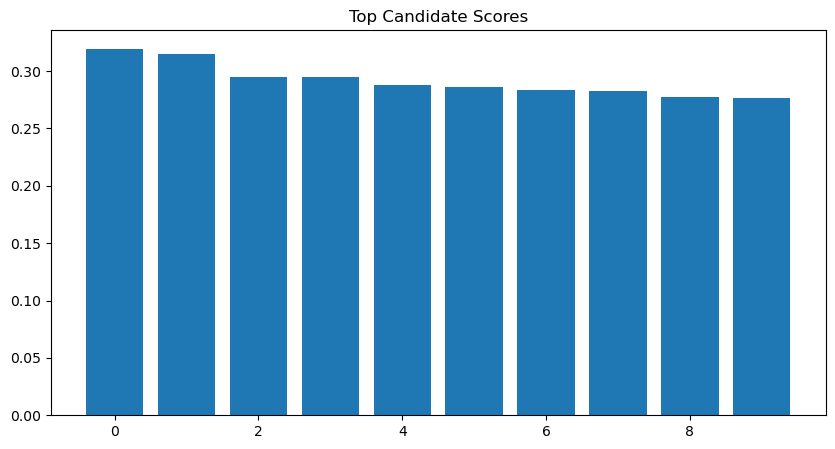

In [14]:
top10 = df_sorted.head(10)

plt.figure(figsize=(10,5))
plt.bar(range(len(top10)), top10['score'])
plt.title("Top Candidate Scores")
plt.savefig("visuals/top_candidates.png")
plt.show()

In [15]:
with open("model.pkl", "wb") as f:
    pickle.dump(vectorizer, f)